# Pima Indians Diabetes — 딥러닝 이진 분류 실습

**데이터**: `pandas/data/diabetes.csv`
**목표**: 당뇨병 발병 여부(`Outcome`) 예측 — **이진 분류(Binary Classification)**

## 학습 흐름
1. 데이터 탐색적 분석 (EDA)
2. 시각화 분석
3. 데이터 전처리
4. 데이터 분할
5. 딥러닝 학습 (Baseline)
6. 결과 분석
7. 모델 개선
8. 개선 결과 분석

## 컬럼 설명
| 컬럼 | 의미 |
|------|------|
| Pregnancies | 임신 횟수 |
| Glucose | 포도당 수치 |
| BloodPressure | 혈압 |
| SkinThickness | 피부 두께 |
| Insulin | 인슐린 |
| BMI | 체질량지수 |
| DiabetesPedigreeFunction | 당뇨 가족력 지수 |
| Age | 나이 |
| **Outcome** | 당뇨 여부 (0/1) — 타겟 |

## 1. 데이터 탐색적 분석 (EDA)

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

df = pd.read_csv('pandas/data/diabetes.csv')
print(f'데이터 shape: {df.shape}')
df.head()

데이터 shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [75]:
# 통계 요약
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [76]:
# 타겟 분포
print('=== Outcome 분포 ===')
print(df['Outcome'].value_counts())
print(f'\n당뇨 발병률: {df["Outcome"].mean():.4f}')

=== Outcome 분포 ===
Outcome
0    500
1    268
Name: count, dtype: int64

당뇨 발병률: 0.3490


In [77]:
# 0값 확인 — Pima 데이터셋의 특성: 결측치가 0으로 기록되어 있음
# Glucose, BloodPressure, SkinThickness, Insulin, BMI는 0이 될 수 없음
zero_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('=== 0값 개수 (사실상 결측치) ===')
for col in zero_check:
  cnt = (df[col] == 0).sum()
  print(f'  {col:20s}: {cnt:4d} ({cnt/len(df)*100:.1f}%)')

=== 0값 개수 (사실상 결측치) ===
  Glucose             :    5 (0.7%)
  BloodPressure       :   35 (4.6%)
  SkinThickness       :  227 (29.6%)
  Insulin             :  374 (48.7%)
  BMI                 :   11 (1.4%)


## 2. 시각화 분석

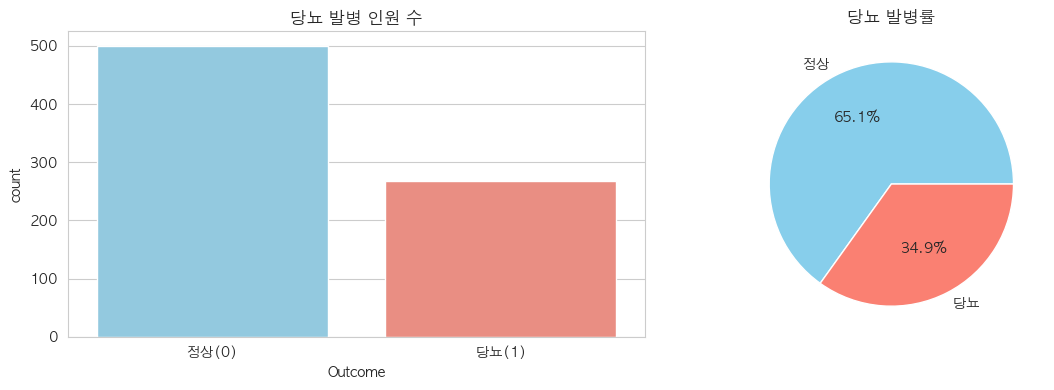

In [78]:
# 1) 타겟 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Outcome', ax=axes[0], palette=['skyblue', 'salmon'])
axes[0].set_title('당뇨 발병 인원 수')
axes[0].set_xticklabels(['정상(0)', '당뇨(1)'])

df['Outcome'].value_counts().plot.pie(
  ax=axes[1], autopct='%.1f%%', colors=['skyblue', 'salmon'],
  labels=['정상', '당뇨']
)
axes[1].set_ylabel('')
axes[1].set_title('당뇨 발병률')

plt.tight_layout()
plt.show()

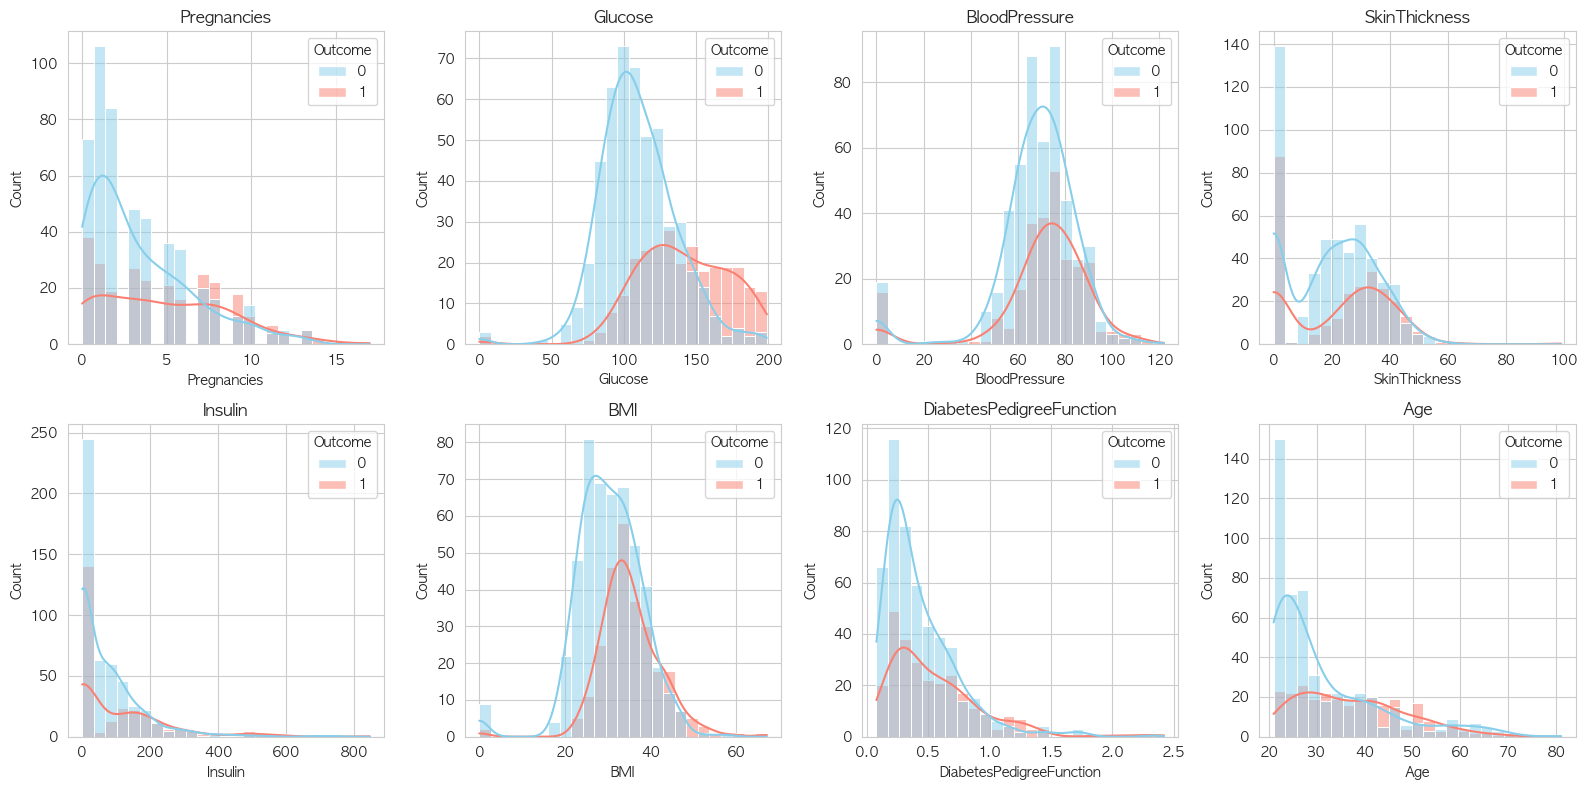

In [79]:
# 2) feature별 분포 (Outcome별 비교)
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, features):
  sns.histplot(data=df, x=col, hue='Outcome', kde=True, bins=25,
               ax=ax, palette=['skyblue', 'salmon'])
  ax.set_title(col)

plt.tight_layout()
plt.show()

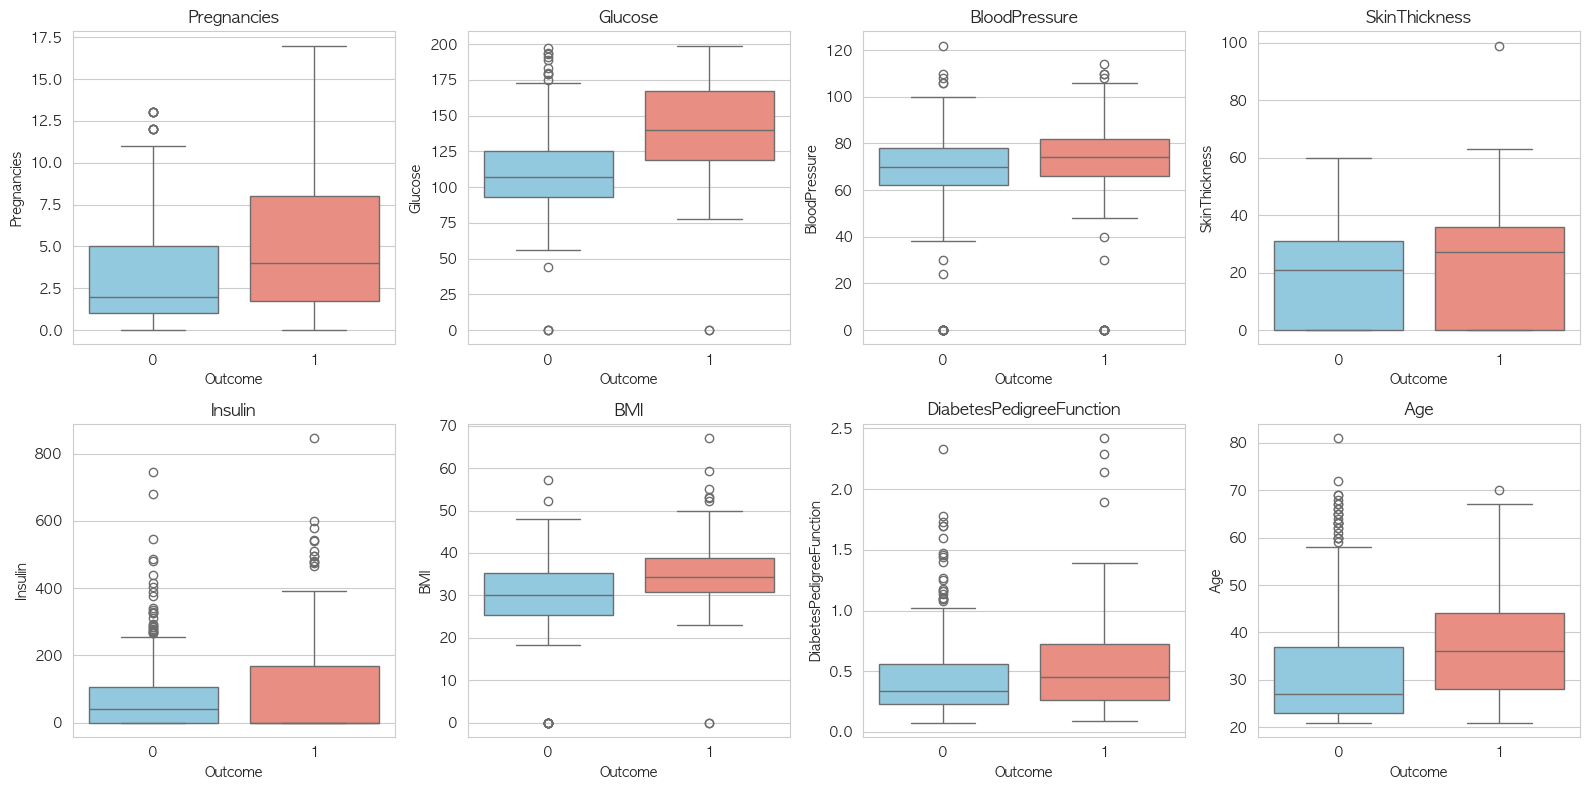

In [80]:
# 3) 박스플롯으로 Outcome별 분포 비교
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, features):
  sns.boxplot(data=df, x='Outcome', y=col, ax=ax, palette=['skyblue', 'salmon'])
  ax.set_title(col)

plt.tight_layout()
plt.show()

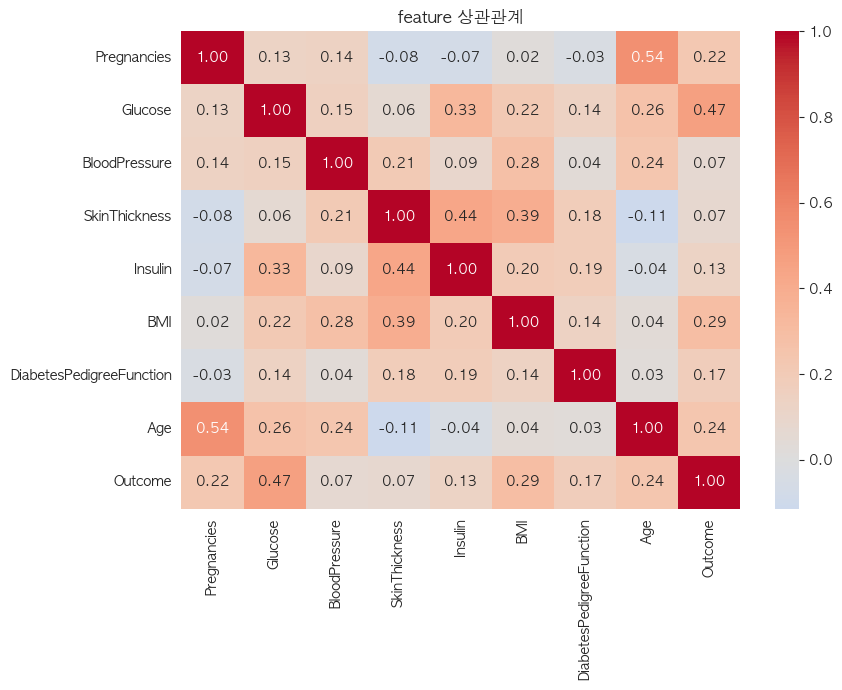

→ Glucose, BMI, Age가 Outcome과 가장 상관 높음


In [81]:
# 4) 상관관계 히트맵
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('feature 상관관계')
plt.tight_layout()
plt.show()
print('→ Glucose, BMI, Age가 Outcome과 가장 상관 높음')

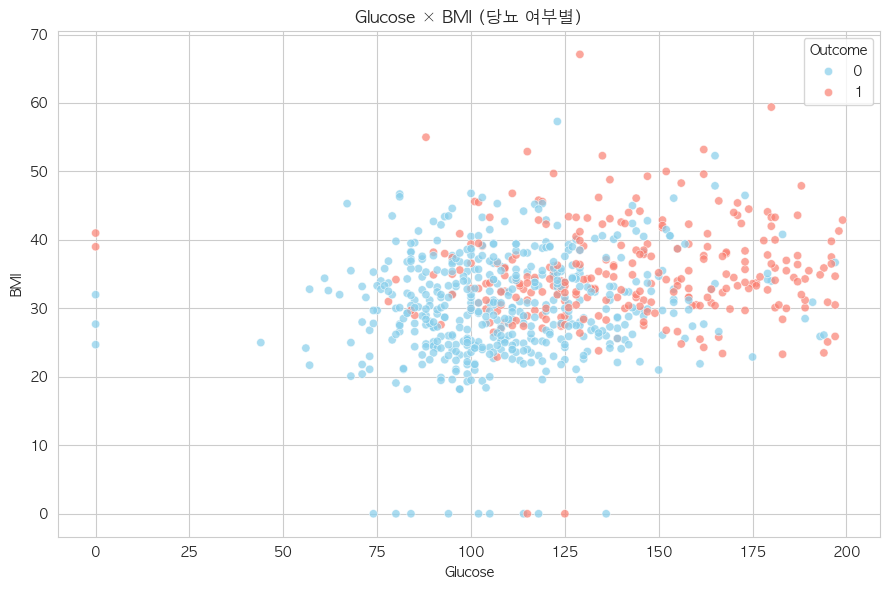

In [82]:
# 5) Glucose vs BMI 산점도 (당뇨 여부별)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome',
                palette=['skyblue', 'salmon'], alpha=0.7)
plt.title('Glucose × BMI (당뇨 여부별)')
plt.tight_layout()
plt.show()

## 3. 데이터 전처리

### 핵심 처리
- **0값 → NaN으로 변환 후 중앙값으로 대체** (Glucose, BP, Skin, Insulin, BMI)
- **StandardScaler 스케일링**

Pima 데이터셋의 가장 큰 특징은 **결측치가 0으로 기록**되어 있다는 점입니다.
(혈압이 0인 사람은 없으므로 명백한 결측치)

In [83]:
df_p = df.copy()

# 0이 결측치인 컬럼 → NaN → 중앙값 대체
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
  df_p[col] = df_p[col].replace(0, np.nan)
  df_p[col] = df_p[col].fillna(df_p[col].median())

print(f'결측치 합계: {df_p.isnull().sum().sum()}')
print(f'전처리 후 shape: {df_p.shape}')

결측치 합계: 0
전처리 후 shape: (768, 9)


## 4. 데이터 분할
- Train / Test = 80 / 20
- `stratify`로 클래스 비율 유지
- StandardScaler 적용

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_p.drop('Outcome', axis=1)
y = df_p['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

print(f'X_train: {X_train_s.shape}, X_test: {X_test_s.shape}')
print(f'train 발병률: {y_train.mean():.4f}, test 발병률: {y_test.mean():.4f}')

X_train: (614, 8), X_test: (154, 8)
train 발병률: 0.3485, test 발병률: 0.3506


## 5. 딥러닝 학습 — Baseline
- 은닉층 2개 (Dense 32 → 16, ReLU)
- 출력층: `Dense(1, sigmoid)`
- loss: `binary_crossentropy`

In [85]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

tf.random.set_seed(42)
np.random.seed(42)

input_dim = X_train_s.shape[1]

baseline = Sequential([
  layers.Dense(32, activation='relu', input_shape=(input_dim,)),
  layers.Dense(16, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

baseline.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)
baseline.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_19 (Dense)            (None, 32)                288       
                                                                 
 dense_20 (Dense)            (None, 16)                528       
                                                                 
 dense_21 (Dense)            (None, 1)                 17        
                                                                 
Total params: 833 (3.25 KB)
Trainable params: 833 (3.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [86]:
history_base = baseline.fit(
  X_train_s, y_train,
  validation_split=0.2,
  epochs=100,
  batch_size=32,
  verbose=0
)
print(f'학습 완료 (epoch={len(history_base.history["loss"])})')

학습 완료 (epoch=100)


## 6. 결과 분석 (Baseline)
- 학습 곡선
- 평가 지표 (Accuracy, Precision, Recall, F1, AUC)
- 혼동 행렬

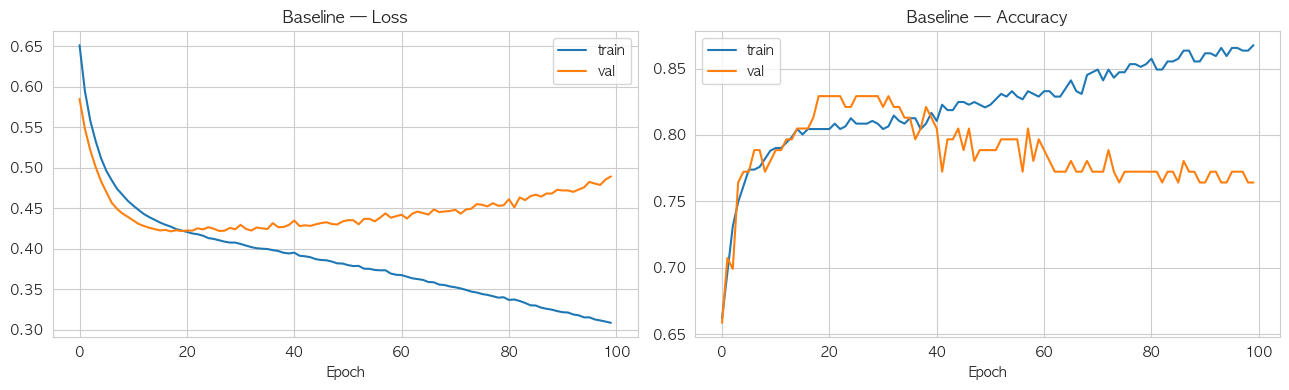

In [87]:
# 학습 곡선 함수 (재사용)
def plot_history(history, title='Learning Curve'):
  fig, axes = plt.subplots(1, 2, figsize=(13, 4))
  axes[0].plot(history.history['loss'], label='train')
  axes[0].plot(history.history['val_loss'], label='val')
  axes[0].set_title(f'{title} — Loss')
  axes[0].set_xlabel('Epoch')
  axes[0].legend()
  axes[1].plot(history.history['accuracy'], label='train')
  axes[1].plot(history.history['val_accuracy'], label='val')
  axes[1].set_title(f'{title} — Accuracy')
  axes[1].set_xlabel('Epoch')
  axes[1].legend()
  plt.tight_layout()
  plt.show()

plot_history(history_base, 'Baseline')

In [88]:
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score, f1_score,
  roc_auc_score, confusion_matrix, classification_report
)

results = {}

def evaluate_clf(name, model, X_te, y_te):
  prob = model.predict(X_te, verbose=0).flatten()
  pred = (prob >= 0.5).astype(int)
  metrics = {
    'Accuracy': accuracy_score(y_te, pred),
    'Precision': precision_score(y_te, pred),
    'Recall': recall_score(y_te, pred),
    'F1': f1_score(y_te, pred),
    'AUC': roc_auc_score(y_te, prob),
  }
  results[name] = metrics
  print(f'=== [{name}] ===')
  for k, v in metrics.items():
    print(f'  {k:10s}: {v:.4f}')
  return pred, prob

pred_base, prob_base = evaluate_clf('Baseline', baseline, X_test_s, y_test)

=== [Baseline] ===
  Accuracy  : 0.7597
  Precision : 0.6735
  Recall    : 0.6111
  F1        : 0.6408
  AUC       : 0.8219


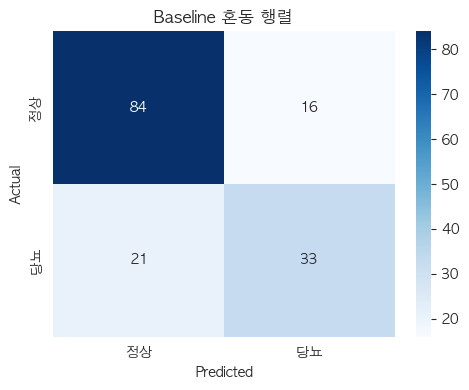

              precision    recall  f1-score   support

          정상       0.80      0.84      0.82       100
          당뇨       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [89]:
cm = confusion_matrix(y_test, pred_base)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상', '당뇨'], yticklabels=['정상', '당뇨'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline 혼동 행렬')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_base, target_names=['정상', '당뇨']))

## 7. 모델 개선

### 핵심 통찰: 모델을 더 **작게**
이전에 구조를 키우거나 Dropout/L2를 강화해도 과적합이 반복됐습니다.

**원인은 샘플 수 대비 모델 용량입니다.**
- 훈련 샘플: ~490개
- Baseline 파라미터: ~900개 → 이미 샘플보다 많음

이런 상황에서 깊이/너비를 늘리면 모델이 훈련 데이터를 **암기**하게 됩니다.
해법은 역발상 — **모델을 더 작게** 만들어 용량을 샘플 수에 맞추는 것입니다.

### 개선 포인트
| 항목 | Baseline | Improved |
|------|---------|----------|
| 구조 | Dense 32 → 16 | **Dense 16 → 8** (축소) |
| L2 규제 | 없음 | **l2(1e-3)** |
| Dropout | 없음 | **0.2** (1회) |
| EarlyStopping | 없음 | **patience=20** |

In [90]:
from tensorflow.keras import callbacks, optimizers, regularizers

tf.random.set_seed(42)
np.random.seed(42)

# 샘플 수(~490)에 맞춰 모델을 더 작게
# 파라미터 수가 샘플 수를 초과하면 반드시 과적합
l2 = regularizers.l2(1e-3)

improved = Sequential([
  layers.Dense(16, input_shape=(input_dim,),
               activation='relu', kernel_regularizer=l2),
  layers.Dropout(0.2),
  layers.Dense(8, activation='relu', kernel_regularizer=l2),
  layers.Dense(1, activation='sigmoid')
])

improved.compile(
  optimizer=optimizers.Adam(learning_rate=1e-3),
  loss='binary_crossentropy',
  metrics=['accuracy']
)
improved.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 16)                144       
                                                                 
 dropout_5 (Dropout)         (None, 16)                0         
                                                                 
 dense_23 (Dense)            (None, 8)                 136       
                                                                 
 dense_24 (Dense)            (None, 1)                 9         
                                                                 
Total params: 289 (1.13 KB)
Trainable params: 289 (1.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [91]:
early_stop = callbacks.EarlyStopping(
  monitor='val_loss', patience=20, restore_best_weights=True
)

history_imp = improved.fit(
  X_train_s, y_train,
  validation_split=0.2,
  epochs=200,
  batch_size=32,
  callbacks=[early_stop],
  verbose=0
)
print(f'학습 완료 (epoch={len(history_imp.history["loss"])})')

학습 완료 (epoch=92)


## 8. 개선 결과 분석 및 비교

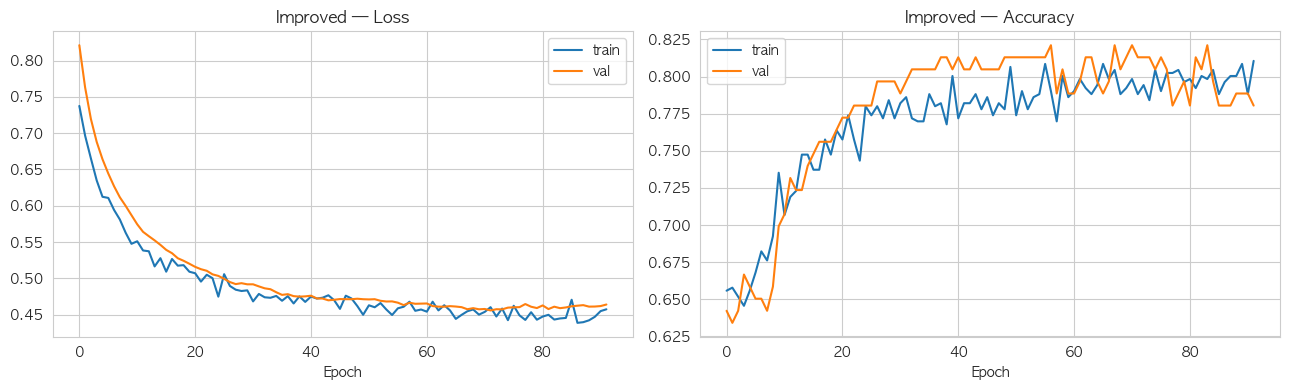

In [92]:
plot_history(history_imp, 'Improved')

In [93]:
pred_imp, prob_imp = evaluate_clf('Improved', improved, X_test_s, y_test)

=== [Improved] ===
  Accuracy  : 0.7468
  Precision : 0.6415
  Recall    : 0.6296
  F1        : 0.6355
  AUC       : 0.8100


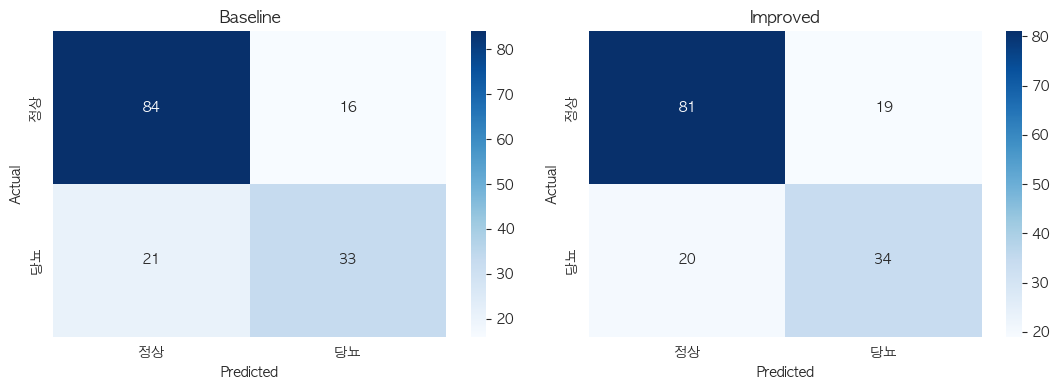

In [94]:
# 두 모델 혼동 행렬 비교
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, pred in zip(axes, ['Baseline', 'Improved'], [pred_base, pred_imp]):
  cm = confusion_matrix(y_test, pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
              xticklabels=['정상', '당뇨'], yticklabels=['정상', '당뇨'])
  ax.set_title(name)
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

=== 모델 성능 비교 ===
          Accuracy  Precision  Recall      F1     AUC
Baseline    0.7597     0.6735  0.6111  0.6408  0.8219
Improved    0.7468     0.6415  0.6296  0.6355  0.8100


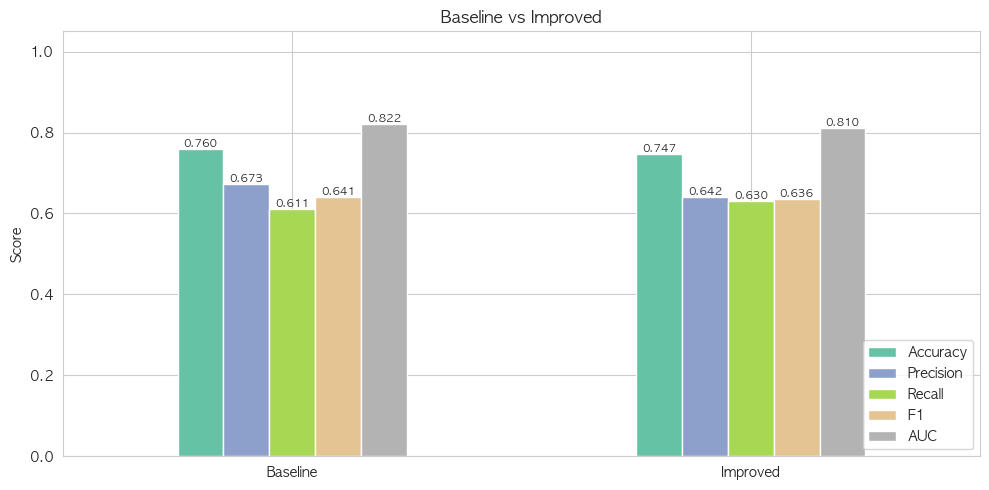

In [95]:
result_df = pd.DataFrame(results).T
print('=== 모델 성능 비교 ===')
print(result_df.round(4))

ax = result_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
ax.set_title('Baseline vs Improved')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
for c in ax.containers:
  ax.bar_label(c, fmt='%.3f', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

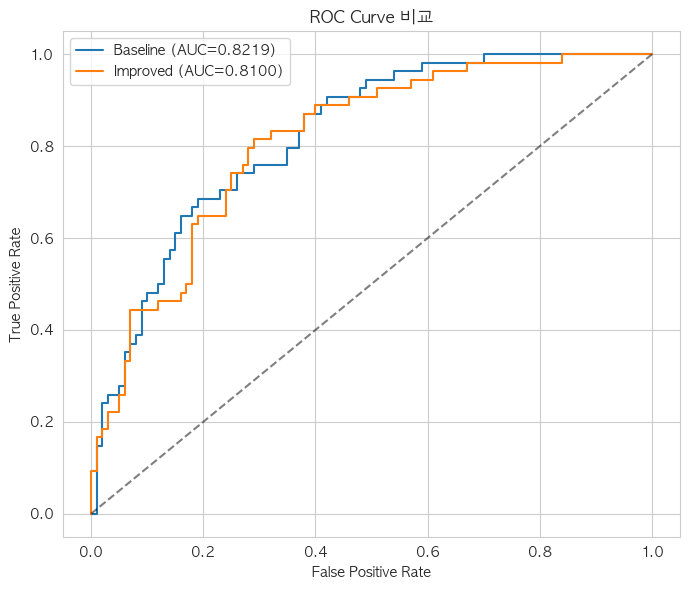

In [96]:
# ROC Curve 비교
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, prob in [('Baseline', prob_base), ('Improved', prob_imp)]:
  fpr, tpr, _ = roc_curve(y_test, prob)
  auc = roc_auc_score(y_test, prob)
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve 비교')
plt.legend()
plt.tight_layout()
plt.show()

## 9. sklearn 모델과 비교 — DL의 한계 확인

**작은 tabular 데이터에서는 tree 계열 / 선형 모델이 DL을 능가하는 것이 일반적**입니다.
Pima처럼 768개 샘플 수준에서는 DL이 LogisticRegression, GradientBoosting에 대부분 밀립니다.
이는 모델의 문제가 아니라 **데이터 특성과 모델 궁합의 문제**입니다.

=== 전체 모델 비교 ===
                    Accuracy  Precision  Recall      F1     AUC
Baseline              0.7597     0.6735  0.6111  0.6408  0.8219
Improved              0.7468     0.6415  0.6296  0.6355  0.8100
LogisticRegression    0.7078     0.6000  0.5000  0.5455  0.8130
RandomForest          0.7468     0.6596  0.5741  0.6139  0.8173
GradientBoosting      0.7597     0.6889  0.5741  0.6263  0.8307


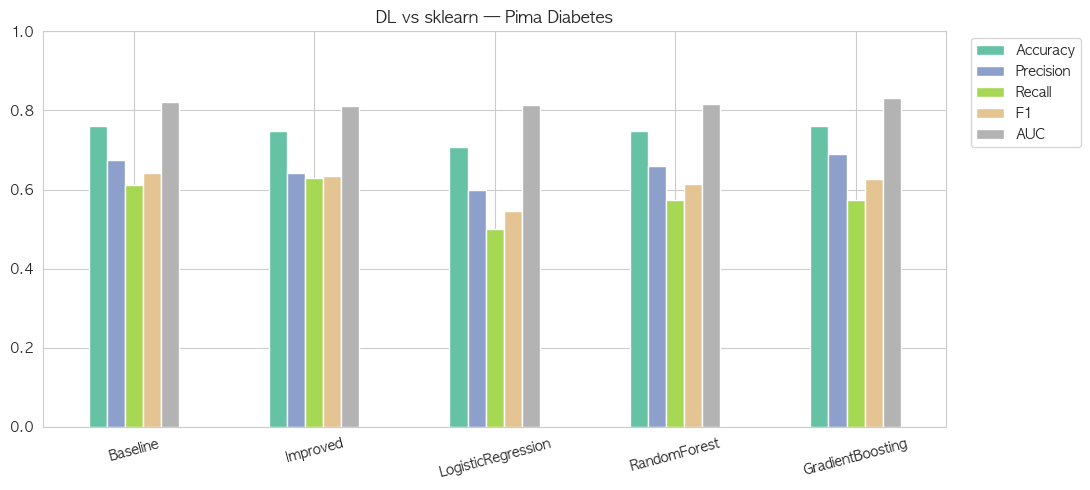

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

sk_models = {
  'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
  'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
  'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

for name, m in sk_models.items():
  m.fit(X_train_s, y_train)
  prob = m.predict_proba(X_test_s)[:, 1]
  pred = (prob >= 0.5).astype(int)
  results[name] = {
    'Accuracy':  accuracy_score(y_test, pred),
    'Precision': precision_score(y_test, pred),
    'Recall':    recall_score(y_test, pred),
    'F1':        f1_score(y_test, pred),
    'AUC':       roc_auc_score(y_test, prob),
  }

result_df = pd.DataFrame(results).T.round(4)
print('=== 전체 모델 비교 ===')
print(result_df)

ax = result_df.plot(kind='bar', figsize=(11, 5), colormap='Set2')
ax.set_title('DL vs sklearn — Pima Diabetes')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 정리

### Pima Diabetes 데이터의 핵심 포인트
- **결측치가 0으로 기록**되어 있다는 점이 가장 중요
  - Glucose=0, BMI=0 등은 명백한 결측치
  - 0을 그대로 학습시키면 성능이 크게 떨어짐
- 클래스 불균형 (정상 65% / 당뇨 35%) — 약한 불균형
- Glucose, BMI, Age가 가장 중요한 feature

### 의료 도메인에서의 평가 우선순위
- **Recall 우선**: 당뇨 환자를 놓치면 안 되므로
- 단순 Accuracy보다 **F1, AUC, Recall**을 중시
- 필요 시 threshold를 0.4~0.45로 낮춰 Recall 추가 향상

### 시험 출제 포인트
- 이진 분류: `Dense(1, sigmoid)` + `binary_crossentropy`
- 학습 곡선에서 train/val 차이로 과적합 진단
- 혼동 행렬 해석 (TP/FP/TN/FN)
- ROC Curve와 AUC의 의미